# Wi‑Fi CSI 6명 / 5RX 자세추정 학습 — ZIP 입력 버전

대상 사람:
**유정 · 동오 · 지원 · 민영 · 예담 · 다훈**

현재 프로젝트 기준:
- Google Drive에는 **세션별 ZIP 파일만 저장**
- 예: `1002_21시_모션.zip`, `1003_11시_모션.zip`, `1003_13시_모션.zip`, `1003_15시_모션.zip`
- ZIP은 Colab 로컬 `/content`로 복사 후 압축 해제
- 압축 해제 CSV와 전처리 NPZ는 **Colab 로컬에만 저장**
- Google Drive에는 **최종 모델/INT8/FPGA bin/학습 로그만 저장**
- RX = 5개
- 입력 = `[B, 15, 128, 10]` = 5RX × (base/delta/mask)
- Window = 10, stride = 1
- 동작 = 팔 / 다리 / 스쿼트 / 정자세
- 학습 sampling 목표 = **팔 30% / 다리 30% / 스쿼트 30% / 정자세 10%**
- 사람 6명도 가능한 한 동일 비율로 sampling
- 일반 ZIP 세션은 **Train / Val**
- ZIP 이름 또는 CSV 이름에 `테스트`가 있으면 **Test 전용**
- Test 데이터가 없어도 정상 학습 가능
- Best FP32 → INT8 calibration/export → **5RX FPGA `.bin`** 생성

### 세션 분할
같은 시간대 ZIP 전체를 하나의 세션으로 봅니다.

일반 세션이 현재 4개라면:
- **Train 3세션**
- **Val 1세션**
- **Test 없음**

나중에 `1004_11시_모션_테스트.zip`처럼 별도 ZIP을 넣으면 그 ZIP은 **Test 전용**입니다.

> Colab에서 **런타임 → 런타임 유형 변경 → T4 GPU**를 먼저 선택하세요.


In [1]:
import torch
import sys

print("Python:", sys.executable)
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: /usr/bin/python3
CUDA: False


In [2]:

# 1) Google Drive 연결
from google.colab import drive  # pyright: ignore[reportMissingImports]
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:

# 2) 경로/학습 설정 - 보통 여기만 수정하면 됨
from pathlib import Path

# Google Drive: 세션별 ZIP들이 들어 있는 폴더
ZIP_ROOT = Path("/content/drive/MyDrive/wifi_csi/dataset")

# Google Drive: 최종 결과만 저장할 폴더
RUN_ROOT = Path("/content/drive/MyDrive/wifi_csi/runs")
RUN_NAME = "6people_5rx_zip_v1"
RUN_DIR = RUN_ROOT / RUN_NAME

# Colab 로컬: 대용량 임시 작업 공간
LOCAL_ROOT = Path("/content/wifi_csi_local")
LOCAL_ZIP_ROOT = LOCAL_ROOT / "zips"
EXTRACT_ROOT = LOCAL_ROOT / "extracted"
CACHE_DIR = LOCAL_ROOT / "cache" / RUN_NAME

PEOPLE = ["유정", "동오", "지원", "민영", "예담", "다훈"]

RX_COUNT = 5
SUBCARRIERS = 128
WINDOW = 10
WINDOW_STRIDE = 1

BATCH_SIZE = 64
EPOCHS = 50
LEARNING_RATE = 2e-4
WEIGHT_DECAY = 1e-4
EARLY_STOPPING = 8
SEED = 42

ACTION_TARGET = {
    "arms": 0.30,
    "legs": 0.30,
    "squat": 0.30,
    "neutral": 0.10,
}

# Drive에서 ZIP을 /content로 먼저 복사한 뒤 압축 해제
COPY_ZIPS_TO_LOCAL = True

# 같은 런타임에서 다시 실행할 때 이미 압축 해제된 세션은 재사용
FORCE_REEXTRACT = False

# 기존 결과 폴더 보호
ALLOW_OVERWRITE = False

print("ZIP_ROOT    =", ZIP_ROOT)
print("RUN_DIR     =", RUN_DIR)
print("EXTRACT_ROOT=", EXTRACT_ROOT)
print("CACHE_DIR   =", CACHE_DIR)


ZIP_ROOT    = /content/drive/MyDrive/wifi_csi/dataset
RUN_DIR     = /content/drive/MyDrive/wifi_csi/runs/6people_5rx_zip_v1
EXTRACT_ROOT= /content/wifi_csi_local/extracted
CACHE_DIR   = /content/wifi_csi_local/cache/6people_5rx_zip_v1


In [3]:

# 3) 환경 확인 + 참고 저장소 준비
import os, sys, subprocess, shutil, random, re, json, math, struct, time, zipfile
import numpy as np
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

REF_ROOT = Path("/content/wifi-csi-pose")

if not REF_ROOT.exists():
    subprocess.run([
        "git", "clone", "--depth", "1",
        "https://github.com/ziziccc/wifi-csi-pose.git",
        str(REF_ROOT)
    ], check=True)
else:
    print("reference repo already exists:", REF_ROOT)

SRC = REF_ROOT / "ML" / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from prepare import _save_split
from data import CachedWindowDataset
from original_models import build_model
from training import _run_epoch, _set_seed
from int8_export import calibrate_fast_model, export_fast_cnn_int8

print("Reference modules loaded from:", SRC)


PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
Reference modules loaded from: /content/wifi-csi-pose/ML/src


## Drive 파일 구성

지금처럼 넣으면 됩니다.

```text
MyDrive/
└─ wifi_csi/
   └─ dataset/
      ├─ 1002_21시_모션.zip
      ├─ 1003_11시_모션.zip
      ├─ 1003_13시_모션.zip
      └─ 1003_15시_모션.zip
```

ZIP 내부는 폴더가 한 번 더 들어가 있어도 상관없습니다. 내부를 재귀적으로 찾아서 `*.csv`를 읽습니다.

예:

```text
1003_15시_모션.zip
└─ 어떤폴더/
   ├─ 1003_15시_지원_팔_1.csv
   ├─ 1003_15시_지원_팔_2.csv
   ├─ 1003_15시_지원_다리_1.csv
   ├─ 1003_15시_지원_스쿼트_1.csv
   └─ 1003_15시_지원_정자세.csv
```

### Test
가능하면 Test는 **ZIP 자체를 별도 세션**으로 만들고 이름에 `테스트`를 넣는 것을 권장합니다.

```text
1004_11시_모션_테스트.zip
```

이 ZIP 전체가 Test가 됩니다.


In [4]:

# 4) 세션 ZIP -> Colab 로컬 복사/압축 해제
assert ZIP_ROOT.exists(), f"ZIP_ROOT가 없습니다: {ZIP_ROOT}"

LOCAL_ZIP_ROOT.mkdir(parents=True, exist_ok=True)
EXTRACT_ROOT.mkdir(parents=True, exist_ok=True)

zip_files = sorted(ZIP_ROOT.glob("*.zip"))
if not zip_files:
    raise FileNotFoundError(f"ZIP 파일이 없습니다: {ZIP_ROOT}")

print("발견한 ZIP:")
total_zip_bytes = 0
for z in zip_files:
    total_zip_bytes += z.stat().st_size
    print(f"  {z.name:40s} {z.stat().st_size / (1024**2):8.1f} MiB")
print(f"총 ZIP 용량: {total_zip_bytes / (1024**3):.2f} GiB")

disk = shutil.disk_usage("/content")
print(f"Colab /content 여유 공간: {disk.free / (1024**3):.1f} GiB")

def open_zip_korean_safe(path: Path):
    # Python 3.11+에서는 UTF-8 플래그 없는 Windows ZIP의 한글 이름도 cp949로 처리 가능
    try:
        return zipfile.ZipFile(path, "r", metadata_encoding="cp949")
    except TypeError:
        return zipfile.ZipFile(path, "r")

def safe_extract_all(zip_path: Path, out_dir: Path):
    marker = out_dir / ".extract_complete"

    if marker.exists() and not FORCE_REEXTRACT:
        print(f"[재사용] {out_dir.name}")
        return

    if out_dir.exists():
        shutil.rmtree(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    with open_zip_korean_safe(zip_path) as zf:
        root = out_dir.resolve()
        for info in zf.infolist():
            # ZIP path traversal 방지
            target = (out_dir / info.filename).resolve()
            if target != root and root not in target.parents:
                raise RuntimeError(f"위험한 ZIP 경로 발견: {info.filename}")
        zf.extractall(out_dir)

    marker.write_text(zip_path.name, encoding="utf-8")
    csv_count = len(list(out_dir.rglob("*.csv")))
    print(f"[압축 해제] {zip_path.name} -> {out_dir} | CSV {csv_count}개")

for drive_zip in zip_files:
    if COPY_ZIPS_TO_LOCAL:
        local_zip = LOCAL_ZIP_ROOT / drive_zip.name
        need_copy = (
            not local_zip.exists()
            or local_zip.stat().st_size != drive_zip.stat().st_size
        )
        if need_copy:
            print(f"[Drive -> local] {drive_zip.name}")
            shutil.copy2(drive_zip, local_zip)
    else:
        local_zip = drive_zip

    session_dir = EXTRACT_ROOT / drive_zip.stem
    safe_extract_all(local_zip, session_dir)

print("\nZIP 준비 완료")


발견한 ZIP:
  1002_21시_모션.zip                         203.9 MiB
  1003_11시_모션.zip                         166.3 MiB
  1003_13시_모션.zip                         157.6 MiB
  1003_15시_모션.zip                         177.3 MiB
  1003_17시_모션.zip                         251.3 MiB
총 ZIP 용량: 0.93 GiB
Colab /content 여유 공간: 71.4 GiB
[Drive -> local] 1002_21시_모션.zip
[압축 해제] 1002_21시_모션.zip -> /content/wifi_csi_local/extracted/1002_21시_모션 | CSV 36개
[Drive -> local] 1003_11시_모션.zip
[압축 해제] 1003_11시_모션.zip -> /content/wifi_csi_local/extracted/1003_11시_모션 | CSV 30개
[Drive -> local] 1003_13시_모션.zip
[압축 해제] 1003_13시_모션.zip -> /content/wifi_csi_local/extracted/1003_13시_모션 | CSV 30개
[Drive -> local] 1003_15시_모션.zip
[압축 해제] 1003_15시_모션.zip -> /content/wifi_csi_local/extracted/1003_15시_모션 | CSV 36개
[Drive -> local] 1003_17시_모션.zip
[압축 해제] 1003_17시_모션.zip -> /content/wifi_csi_local/extracted/1003_17시_모션 | CSV 48개

ZIP 준비 완료


## CSV 인식 규칙

CSV 파일명 또는 ZIP 내부의 하위 폴더 이름에서 다음을 찾습니다.

- 사람: `유정`, `동오`, `지원`, `민영`, `예담`, `다훈`
- 동작:
  - `팔` → `arms`
  - `다리` → `legs`
  - `스쿼트` → `squat`
  - `정자세` → `neutral`

`정자세`는 `_1` 같은 숫자가 없어도 됩니다.

```text
1003_15시_지원_정자세.csv
```

세션은 CSV 파일명이 아니라 **어느 ZIP에서 나왔는지**로 구분합니다.
즉 `1003_15시_모션.zip` 안의 모든 일반 CSV는 같은 세션입니다.


In [11]:

# 5) CSV 인식 / 세션 split 함수
from collections import Counter
from itertools import combinations

def _relative_text(path: Path, session_dir: Path):
    rel = path.relative_to(session_dir)
    return "/".join(rel.parts)

def _find_one_token(text: str, tokens):
    hits = [t for t in tokens if t in text]
    return hits[0] if len(hits) == 1 else None

def person_of(path: Path, session_dir: Path):
    # 1순위: CSV 파일명 자체
    p = _find_one_token(path.name, PEOPLE)
    if p is not None:
        return p

    # 2순위: ZIP 내부에서 가까운 부모 폴더부터 확인.
    # 최상위 폴더 이름에 6명 이름이 모두 들어 있어도 오인하지 않음.
    rel = path.relative_to(session_dir)
    for part in reversed(rel.parts[:-1]):
        p = _find_one_token(part, PEOPLE)
        if p is not None:
            return p
    return None

def _action_from_text(text: str):
    if "정자세" in text:
        return "neutral"
    if "스쿼트" in text:
        return "squat"
    if "다리" in text:
        return "legs"
    if "팔" in text:
        return "arms"
    return None

def action_of(path: Path, session_dir: Path):
    # 1순위: CSV 파일명
    a = _action_from_text(path.name)
    if a is not None:
        return a

    # 2순위: ZIP 내부 가까운 부모 폴더
    rel = path.relative_to(session_dir)
    for part in reversed(rel.parts[:-1]):
        a = _action_from_text(part)
        if a is not None:
            return a
    return None

def repeat_index(path: Path):
    m = re.search(r"_(\d+)(?:\.csv){1,2}$", path.name, flags=re.IGNORECASE)
    return int(m.group(1)) if m else None

def scan_extracted(extract_root: Path):
    rows = []
    ignored = []

    session_dirs = sorted(
        d for d in extract_root.iterdir()
        if d.is_dir()
    )

    for session_dir in session_dirs:
        session_name = session_dir.name
        zip_is_test = "테스트" in session_name

        for f in sorted(session_dir.rglob("*.csv")):
            if not f.is_file():
                continue

            rel_text = _relative_text(f, session_dir)
            p = person_of(f, session_dir)
            a = action_of(f, session_dir)

            if p is None or a is None:
                ignored.append((session_name, f))
                continue

            rows.append({
                "path": f,
                "person": p,
                "action": a,
                "session": session_name,
                "repeat": repeat_index(f),
                "test_tagged": zip_is_test or ("테스트" in rel_text),
                "source_zip": session_name + ".zip",
            })

    return rows, ignored

def _groups_in(rows):
    return {(r["person"], r["action"]) for r in rows}

def choose_val_sessions(normal_rows, seed=42):
    sessions = sorted({r["session"] for r in normal_rows})
    if len(sessions) < 2:
        raise RuntimeError(
            "일반 ZIP 세션이 2개 미만이라 Train/Val 세션 분할을 할 수 없습니다."
        )

    n = len(sessions)
    n_val = 1 if n <= 5 else max(1, round(n * 0.20))
    n_val = min(n_val, n - 1)

    rng = np.random.default_rng(seed)
    shuffled = list(sessions)
    rng.shuffle(shuffled)

    # 가능한 경우, 어떤 사람×동작이 Train에서 완전히 사라지는 Val 선택은 피함
    all_groups = _groups_in(normal_rows)

    # 세션 수가 보통 작으므로 조합 탐색
    for candidate in combinations(shuffled, n_val):
        val_set = set(candidate)
        remaining = [r for r in normal_rows if r["session"] not in val_set]
        if _groups_in(remaining) == all_groups:
            return val_set

    # 데이터가 너무 적어서 완전 보존이 불가능하면 seed 순서대로 선택
    print("[경고] 모든 사람×동작을 Train에 유지하는 Val 세션 조합이 없습니다.")
    return set(shuffled[:n_val])

def make_split(rows, seed=42):
    """
    Test:
      ZIP 이름 또는 CSV 이름에 '테스트' 포함 -> Test 전용

    Train/Val:
      나머지 일반 ZIP을 세션 단위로 통째로 분할
      2~5세션 -> 1 Val, 나머지 Train
      6세션 이상 -> 약 20% Val
    """
    split = {}

    # 명시적 Test는 먼저 완전히 격리
    for r in rows:
        if r["test_tagged"]:
            split[r["path"]] = "test"

    normal_rows = [r for r in rows if not r["test_tagged"]]
    val_sessions = choose_val_sessions(normal_rows, seed=seed)
    normal_sessions = sorted({r["session"] for r in normal_rows})
    train_sessions = [s for s in normal_sessions if s not in val_sessions]

    for r in normal_rows:
        split[r["path"]] = "val" if r["session"] in val_sessions else "train"

    test_sessions = sorted({
        r["session"] for r in rows
        if r["test_tagged"]
    })

    print("===== SESSION SPLIT =====")
    print("TRAIN:", train_sessions)
    print("VAL  :", sorted(val_sessions))
    print("TEST :", test_sessions if test_sessions else "(없음)")
    print("=========================")

    # 일반 ZIP 안에서 CSV 하나만 '테스트'인 경우 누수 가능성 경고
    partial_test_sessions = sorted({
        r["session"] for r in rows
        if r["test_tagged"] and "테스트" not in r["session"]
    })
    if partial_test_sessions:
        print(
            "[주의] 일반 ZIP 안에 테스트 CSV가 있습니다:",
            partial_test_sessions
        )
        print(
            "최종 Test는 가능하면 별도 '*_테스트.zip' 세션으로 만드는 것을 권장합니다."
        )

    return split


In [12]:

# 6) 압축 해제된 CSV 스캔 + split 확인
assert EXTRACT_ROOT.exists(), f"EXTRACT_ROOT가 없습니다: {EXTRACT_ROOT}"

rows, ignored = scan_extracted(EXTRACT_ROOT)
if not rows:
    raise RuntimeError("인식 가능한 CSV가 없습니다.")

split_map = make_split(rows, SEED)

print(f"\n사용 가능한 CSV: {len(rows)}")
print(f"무시된 CSV:      {len(ignored)}")

count = Counter()
for r in rows:
    s = split_map.get(r["path"], "ignored")
    count[(s, r["person"], r["action"])] += 1

for p in PEOPLE:
    print(f"\n[{p}]")
    for act in ["arms", "legs", "squat", "neutral"]:
        tr = count[("train", p, act)]
        va = count[("val", p, act)]
        te = count[("test", p, act)]
        print(f"  {act:7s} train={tr:2d}  val={va:2d}  test={te:2d}")

print("\n--- 세션/파일 split ---")
for r in rows:
    print(
        f"{split_map[r['path']]:5s} | "
        f"{r['session']:18s} | "
        f"{r['person']:3s} | {r['action']:7s} | "
        f"{r['path'].name}"
    )

missing_people = [
    p for p in PEOPLE
    if not any(
        r["person"] == p and split_map[r["path"]] == "train"
        for r in rows
    )
]
if missing_people:
    raise RuntimeError(f"Train 데이터가 없는 사람: {missing_people}")

missing_groups = []
for p in PEOPLE:
    for act in ACTION_TARGET:
        if not any(
            r["person"] == p
            and r["action"] == act
            and split_map[r["path"]] == "train"
            for r in rows
        ):
            missing_groups.append((p, act))

if missing_groups:
    print("\n[경고] Train에 아직 없는 사람×동작 조합:")
    for g in missing_groups:
        print(" ", g)
    print("정자세를 아직 일부 세션에만 추가한 단계라면 이 경고는 정상일 수 있습니다.")
else:
    print("\nOK: 6명 모두 arms/legs/squat/neutral Train 데이터가 있습니다.")


AssertionError: EXTRACT_ROOT가 없습니다: /content/wifi_csi_local/extracted

In [ ]:

# 7) 각 CSV -> 5RX / 128 subcarrier NPZ 전처리
# 대용량 NPZ cache는 Drive가 아니라 /content 로컬에만 둠

if RUN_DIR.exists():
    if ALLOW_OVERWRITE:
        shutil.rmtree(RUN_DIR)
    else:
        raise FileExistsError(
            f"{RUN_DIR} 가 이미 있습니다.\n"
            "RUN_NAME을 바꾸거나 ALLOW_OVERWRITE=True로 설정하세요."
        )

# 로컬 cache는 같은 RUN_NAME이면 새로 생성
if CACHE_DIR.exists():
    shutil.rmtree(CACHE_DIR)

FP32_DIR = RUN_DIR / "fp32"
INT8_DIR = RUN_DIR / "int8"

CACHE_DIR.mkdir(parents=True, exist_ok=True)
FP32_DIR.mkdir(parents=True, exist_ok=True)
INT8_DIR.mkdir(parents=True, exist_ok=True)

entries = []

for i, r in enumerate(rows):
    f = r["path"]
    split_name = split_map[f]
    fid = f"f{i:04d}"

    _save_split(
        fid,
        [f],
        CACHE_DIR,
        RX_COUNT,
        192,
        128,
        "esp32_htltf_ht40_above_nonstbc",
    )

    entries.append({
        "id": fid,
        "file": f.name,
        "path": str(f),
        "person": r["person"],
        "action": r["action"],
        "session": r["session"],
        "source_zip": r["source_zip"],
        "split": split_name,
    })

manifest_path = RUN_DIR / "manifest.json"
manifest_path.write_text(
    json.dumps(entries, ensure_ascii=False, indent=2),
    encoding="utf-8"
)

print("전처리 완료")
print("로컬 cache :", CACHE_DIR)
print("Drive 결과 :", RUN_DIR)
print("manifest   :", manifest_path)

cache_bytes = sum(
    p.stat().st_size for p in CACHE_DIR.rglob("*") if p.is_file()
)
print(f"로컬 NPZ cache 용량: {cache_bytes / (1024**3):.2f} GiB")


[f0000] processing 1002_21시_다훈_다리_1.csv
[f0000] 1002_21시_다훈_다리_1.csv: +4747 frames
[f0001] processing 1002_21시_다훈_다리_2.csv
[f0001] 1002_21시_다훈_다리_2.csv: +4737 frames
[f0002] processing 1002_21시_다훈_스쿼트_1.csv
[f0002] 1002_21시_다훈_스쿼트_1.csv: +2275 frames
[f0003] processing 1002_21시_다훈_스쿼트_2.csv
[f0003] 1002_21시_다훈_스쿼트_2.csv: +2340 frames
[f0004] processing 1002_21시_다훈_팔_1.csv
[f0004] 1002_21시_다훈_팔_1.csv: +2256 frames
[f0005] processing 1002_21시_다훈_팔_2.csv
[f0005] 1002_21시_다훈_팔_2.csv: +2339 frames
[f0006] processing 1002_21시_동오_다리_1.csv
[f0006] 1002_21시_동오_다리_1.csv: +4499 frames
[f0007] processing 1002_21시_동오_다리_2.csv
[f0007] 1002_21시_동오_다리_2.csv: +4553 frames
[f0008] processing 1002_21시_동오_스쿼트_1.csv
[f0008] 1002_21시_동오_스쿼트_1.csv: +2246 frames
[f0009] processing 1002_21시_동오_스쿼트_2.csv
[f0009] 1002_21시_동오_스쿼트_2.csv: +2190 frames
[f0010] processing 1002_21시_동오_팔_1.csv
[f0010] 1002_21시_동오_팔_1.csv: +2308 frames
[f0011] processing 1002_21시_동오_팔_2.csv
[f0011] 1002_21시_동오_팔_2.csv: +2298 frames
[f00

In [ ]:

# 8) Dataset 구성

from torch.utils.data import ConcatDataset, DataLoader, WeightedRandomSampler, Subset

def build_concat_dataset(mode):
    selected = [e for e in entries if e["split"] == mode]
    if not selected:
        raise RuntimeError(f"{mode} 데이터가 없습니다.")

    parts = []
    window_file_ids = []

    for file_i, e in enumerate(selected):
        ds = CachedWindowDataset(
            CACHE_DIR / f"{e['id']}.npz",
            WINDOW,
            WINDOW_STRIDE,
            feature_mode="all",
            require_full_window_mask=False,
            fill_mode="forward_fill",
            max_gap=3,
        )

        if len(ds) == 0:
            raise RuntimeError(f"유효 window 없음: {e['file']}")

        x0, y0 = ds[0]
        expected = (RX_COUNT * 3, SUBCARRIERS, WINDOW)
        if tuple(x0.shape) != expected:
            raise RuntimeError(
                f"{e['file']}: input shape={tuple(x0.shape)}, expected={expected}"
            )

        parts.append(ds)
        window_file_ids.append(np.full(len(ds), file_i, dtype=np.int32))

    return (
        ConcatDataset(parts),
        selected,
        parts,
        np.concatenate(window_file_ids)
    )

train_ds, train_entries, train_parts, train_window_file_ids = build_concat_dataset("train")
val_ds, val_entries, val_parts, val_window_file_ids = build_concat_dataset("val")

test_entries_raw = [e for e in entries if e["split"] == "test"]
if test_entries_raw:
    test_ds, test_entries, test_parts, test_window_file_ids = build_concat_dataset("test")
else:
    test_ds = None
    test_entries = []
    test_parts = []
    test_window_file_ids = np.array([], dtype=np.int32)

print("train windows:", len(train_ds))
print("val windows:  ", len(val_ds))
print("test windows: ", 0 if test_ds is None else len(test_ds))
print("input shape:  ", train_ds[0][0].shape)
print("target shape: ", train_ds[0][1].shape)


train windows: 426296
val windows:   83564
test windows:  0
input shape:   torch.Size([15, 128, 10])
target shape:  torch.Size([24])


In [ ]:

# 9) 6명 균형 + 동작 비율(30/30/30/10) sampler

def make_balanced_weights(entries_for_split, window_file_ids):
    # file -> (person, action)
    file_groups = [(e["person"], e["action"]) for e in entries_for_split]
    window_groups = [file_groups[int(fid)] for fid in window_file_ids]

    group_counts = Counter(window_groups)

    people_present = sorted({p for p, a in group_counts})
    if not people_present:
        raise RuntimeError("학습 group이 없습니다.")

    # 사람별 존재하는 action 안에서 ACTION_TARGET을 재정규화
    target_group_prob = {}

    for p in people_present:
        acts = [a for a in ACTION_TARGET if (p, a) in group_counts]
        denom = sum(ACTION_TARGET[a] for a in acts)
        if denom <= 0:
            continue

        person_prob = 1.0 / len(people_present)
        for a in acts:
            target_group_prob[(p, a)] = (
                person_prob * ACTION_TARGET[a] / denom
            )

    weights = np.empty(len(window_groups), dtype=np.float64)

    for i, g in enumerate(window_groups):
        weights[i] = target_group_prob[g] / group_counts[g]

    weights /= weights.sum()

    print("===== sampler 목표 비율 =====")
    for p in people_present:
        print(f"\n[{p}]")
        for a in ACTION_TARGET:
            g = (p, a)
            if g in group_counts:
                print(
                    f"  {a:6s}: windows={group_counts[g]:6d}, "
                    f"target={target_group_prob[g]*100:5.2f}%"
                )
            else:
                print(f"  {a:6s}: 없음")

    print("\n전체 action 목표:")
    for a, w in ACTION_TARGET.items():
        print(f"  {a:6s}: {w*100:.1f}%")
    print("============================")

    return weights

train_weights = make_balanced_weights(train_entries, train_window_file_ids)

sampler_generator = torch.Generator()
sampler_generator.manual_seed(SEED)

train_sampler = WeightedRandomSampler(
    weights=torch.as_tensor(train_weights, dtype=torch.double),
    num_samples=len(train_ds),
    replacement=True,
    generator=sampler_generator,
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=True,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=True,
)


===== sampler 목표 비율 =====

[다훈]
  arms  : windows= 17535, target= 5.00%
  legs  : windows= 34863, target= 5.00%
  squat : windows= 17330, target= 5.00%
  neutral: windows=  4767, target= 1.67%

[동오]
  arms  : windows= 13475, target= 5.00%
  legs  : windows= 26071, target= 5.00%
  squat : windows= 12238, target= 5.00%
  neutral: windows=  4662, target= 1.67%

[민영]
  arms  : windows= 17764, target= 5.00%
  legs  : windows= 34793, target= 5.00%
  squat : windows= 17583, target= 5.00%
  neutral: windows=  4627, target= 1.67%

[예담]
  arms  : windows= 17590, target= 5.00%
  legs  : windows= 33781, target= 5.00%
  squat : windows= 17487, target= 5.00%
  neutral: windows=  4332, target= 1.67%

[유정]
  arms  : windows= 17872, target= 5.00%
  legs  : windows= 34216, target= 5.00%
  squat : windows= 17611, target= 5.00%
  neutral: windows=  4556, target= 1.67%

[지원]
  arms  : windows= 17809, target= 5.00%
  legs  : windows= 34599, target= 5.00%
  squat : windows= 16216, target= 5.00%
  neutral: wi

In [ ]:

# 10) 모델 구성
_set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = build_model(
    "multi_esp_fast_pose_cnn",
    in_channels=RX_COUNT * 3,    # 15
    output_dim=24,
    hidden_dim=128,
    dropout=0.15,
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

criterion = torch.nn.SmoothL1Loss()
scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))

params = sum(p.numel() for p in model.parameters())
print(model)
print()
print("device:", device)
print("parameters:", f"{params:,}")


MultiESPFastPoseCNN(
  (encoder): FastReceiverEncoder(
    (layers): Sequential(
      (0): Conv2d(3, 16, kernel_size=(5, 3), stride=(1, 1), padding=(2, 1), bias=False)
      (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): GELU(approximate='none')
      (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): GELU(approximate='none')
      (6): AdaptiveAvgPool2d(output_size=(8, 4))
    )
  )
  (head): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=5120, out_features=128, bias=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.15, inplace=False)
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): GELU(approximate='none')
    (6): Dropout(p=0.15, inplace=False)
    (7): Linear(in_features=128, out_features=24, bias=True)
  )
)

device: cuda
parameters:

In [ ]:

# 11) validation: 사람×동작을 동일하게 보는 balanced MAE

@torch.inference_mode()
def predict_all(model, ds, batch_size, device):
    loader = DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=(device.type == "cuda"),
    )

    pred_list, target_list = [], []

    model.eval()
    for x, y in loader:
        pred = model(x.float().to(device))
        pred_list.append(pred.cpu().numpy())
        target_list.append(y.numpy())

    return np.concatenate(pred_list), np.concatenate(target_list)

def balanced_val_score(pred, target, entries_for_split, window_file_ids):
    # 각 window의 24좌표 normalized MAE
    sample_mae = np.mean(np.abs(pred - target), axis=1)

    file_groups = [(e["person"], e["action"]) for e in entries_for_split]
    groups = np.array(
        [f"{file_groups[int(fid)][0]}::{file_groups[int(fid)][1]}"
         for fid in window_file_ids],
        dtype=object
    )

    group_scores = {}
    for g in sorted(set(groups.tolist())):
        group_scores[g] = float(sample_mae[groups == g].mean())

    # 데이터 양이 많은 사람/동작 하나가 score를 지배하지 않도록 group 평균
    score = float(np.mean(list(group_scores.values())))

    return score, group_scores


In [ ]:

# 12) 학습
BEST_PATH = FP32_DIR / "best_model.pt"
LAST_PATH = FP32_DIR / "last_model.pt"
HISTORY_PATH = FP32_DIR / "history.json"

best_score = float("inf")
stale = 0
history = []
start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    train_metrics = _run_epoch(
        model,
        train_loader,
        criterion,
        device,
        optimizer,
        scaler,
        epoch,
        EPOCHS,
        "train",
        100,
    )

    pred, target = predict_all(
        model,
        val_ds,
        BATCH_SIZE,
        device,
    )

    val_score, group_scores = balanced_val_score(
        pred,
        target,
        val_entries,
        val_window_file_ids,
    )

    improved = val_score < best_score

    checkpoint = {
        "model_state_dict": model.state_dict(),
        "model_name": "multi_esp_fast_pose_cnn",
        "input_channels": RX_COUNT * 3,
        "selected_rx": [0, 1, 2, 3, 4],
        "epoch": epoch,
        "best_val_score_norm_mae": min(best_score, val_score),
        "config": {
            "model_name": "multi_esp_fast_pose_cnn",
            "hidden_dim": 128,
            "dropout": 0.15,
            "window_size": WINDOW,
            "window_stride": WINDOW_STRIDE,
            "feature_mode": "all",
            "require_full_window_mask": False,
            "fill_mode": "forward_fill",
            "max_gap": 3,
            "rx_count": RX_COUNT,
            "subcarriers": SUBCARRIERS,
            "people": PEOPLE,
            "action_target": ACTION_TARGET,
        },
    }

    torch.save(checkpoint, LAST_PATH)

    if improved:
        best_score = val_score
        stale = 0
        checkpoint["best_val_score_norm_mae"] = best_score
        torch.save(checkpoint, BEST_PATH)
    else:
        stale += 1

    row = {
        "epoch": epoch,
        "train_loss": float(train_metrics["loss"]),
        "train_mae_norm": float(train_metrics["mae_norm"]),
        "val_balanced_mae_norm": val_score,
        "best": best_score,
        "improved": improved,
        "group_scores": group_scores,
    }
    history.append(row)

    HISTORY_PATH.write_text(
        json.dumps(history, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )

    print(
        f"\nEPOCH {epoch:02d} | "
        f"train_loss={train_metrics['loss']:.6f} | "
        f"val_balanced_MAE={val_score:.6f} | "
        f"best={best_score:.6f} | "
        f"{'BEST SAVED' if improved else f'stale={stale}/{EARLY_STOPPING}'}"
    )

    if stale >= EARLY_STOPPING:
        print("\nEARLY STOP")
        break

print("\nDONE")
print("elapsed:", time.time() - start_time, "sec")
print("best model:", BEST_PATH)
print("best val balanced MAE(norm):", best_score)


[train] epoch 001/050 batch 0001/6661 loss=0.125511 mae=0.486967 elapsed=00:03 eta=05:59:00
[train] epoch 001/050 batch 0100/6661 loss=0.013806 mae=0.121126 elapsed=00:05 eta=05:35
[train] epoch 001/050 batch 0200/6661 loss=0.008725 mae=0.094214 elapsed=00:07 eta=03:41
[train] epoch 001/050 batch 0300/6661 loss=0.006655 mae=0.081373 elapsed=00:09 eta=03:02
[train] epoch 001/050 batch 0400/6661 loss=0.005491 mae=0.073404 elapsed=00:10 eta=02:41
[train] epoch 001/050 batch 0500/6661 loss=0.004726 mae=0.067711 elapsed=00:13 eta=02:41
[train] epoch 001/050 batch 0600/6661 loss=0.004178 mae=0.063386 elapsed=00:16 eta=02:37
[train] epoch 001/050 batch 0700/6661 loss=0.003767 mae=0.059995 elapsed=00:17 eta=02:26
[train] epoch 001/050 batch 0800/6661 loss=0.003444 mae=0.057196 elapsed=00:19 eta=02:18
[train] epoch 001/050 batch 0900/6661 loss=0.003181 mae=0.054823 elapsed=00:21 eta=02:12
[train] epoch 001/050 batch 1000/6661 loss=0.002963 mae=0.052793 elapsed=00:22 eta=02:06
[train] epoch 001/

In [ ]:
# ===== v3 학습 결과 확인 전용 - 이 셀 하나만 실행 =====

from pathlib import Path
import json
import matplotlib.pyplot as plt

# v3 결과 폴더
RUN_DIR = Path("/content/drive/MyDrive/wifi_csi/runs/6people_5rx_zip_v1")

HISTORY_PATH = RUN_DIR / "fp32" / "history.json"
BEST_PATH    = RUN_DIR / "fp32" / "best_model.pt"
LAST_PATH    = RUN_DIR / "fp32" / "last_model.pt"
BIN_PATH     = RUN_DIR / "int8" / "weights_5rx.bin"

# --------------------------------------------------
# 1. 파일 확인
# --------------------------------------------------
print("===== FILE CHECK =====")

for name, path in [
    ("history", HISTORY_PATH),
    ("best_model", BEST_PATH),
    ("last_model", LAST_PATH),
    ("FPGA bin", BIN_PATH),
]:
    if path.exists():
        print(f"[OK] {name:12s} : {path}")
        print(f"     size = {path.stat().st_size:,} bytes")
    else:
        print(f"[X]  {name:12s} : 없음")

if not HISTORY_PATH.exists():
    raise FileNotFoundError(f"history.json이 없습니다: {HISTORY_PATH}")

# --------------------------------------------------
# 2. history 불러오기
# --------------------------------------------------
with open(HISTORY_PATH, "r", encoding="utf-8") as f:
    history = json.load(f)

if not history:
    raise RuntimeError("history.json이 비어 있습니다.")

# Validation 기준 Best epoch
best_row = min(
    history,
    key=lambda h: h["val_balanced_mae_norm"]
)

best_epoch = best_row["epoch"]
best_val = best_row["val_balanced_mae_norm"]

print("\n===== BEST RESULT =====")
print(f"Best Epoch          : {best_epoch}")
print(f"Best Validation MAE : {best_val:.6f}")
print(f"Train MAE at Best   : {best_row['train_mae_norm']:.6f}")
print(f"Train Loss at Best  : {best_row['train_loss']:.6f}")

# --------------------------------------------------
# 3. 사람 × 동작 Validation 결과
# --------------------------------------------------
group_scores = best_row.get("group_scores", {})

print("\n===== PERSON × ACTION VALIDATION =====")

if group_scores:
    for group, score in sorted(group_scores.items()):
        print(f"{group:20s} : {score:.6f}")
else:
    print("group_scores가 history에 없습니다.")

# --------------------------------------------------
# 4. 사람별 / 동작별 평균
# --------------------------------------------------
person_scores = {}
action_scores = {}

for group, score in group_scores.items():
    # 저장 형식: "지원::arms" 같은 형태
    if "::" not in group:
        continue

    person, action = group.split("::", 1)

    person_scores.setdefault(person, []).append(score)
    action_scores.setdefault(action, []).append(score)

print("\n===== PERSON AVERAGE =====")
for person, scores in sorted(person_scores.items()):
    avg = sum(scores) / len(scores)
    print(f"{person:6s} : {avg:.6f}")

print("\n===== ACTION AVERAGE =====")
for action, scores in sorted(action_scores.items()):
    avg = sum(scores) / len(scores)
    print(f"{action:8s} : {avg:.6f}")

# --------------------------------------------------
# 5. Train MAE vs Validation MAE
# --------------------------------------------------
epochs = [h["epoch"] for h in history]
train_mae = [h["train_mae_norm"] for h in history]
val_mae = [h["val_balanced_mae_norm"] for h in history]

plt.figure(figsize=(9, 5))
plt.plot(epochs, train_mae, marker="o", label="Train MAE")
plt.plot(epochs, val_mae, marker="o", label="Validation MAE")
plt.axvline(best_epoch, linestyle="--", label=f"Best Epoch = {best_epoch}")

plt.xlabel("Epoch")
plt.ylabel("Normalized MAE")
plt.title("Train vs Validation MAE")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# --------------------------------------------------
# 6. Train Loss
# --------------------------------------------------
train_loss = [h["train_loss"] for h in history]

plt.figure(figsize=(9, 5))
plt.plot(epochs, train_loss, marker="o", label="Train SmoothL1 Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# --------------------------------------------------
# 7. 최종 요약
# --------------------------------------------------
print("\n===== SUMMARY =====")
print(f"Best Epoch : {best_epoch}")
print(f"Best Val   : {best_val:.6f}")
print(f"Model      : {BEST_PATH}")

if BIN_PATH.exists():
    print(f"FPGA BIN   : {BIN_PATH}")
    print(f"BIN size   : {BIN_PATH.stat().st_size:,} bytes")
else:
    print("FPGA BIN   : 아직 생성 안 됨")
    print("             → INT8/export 셀을 실행해야 함")

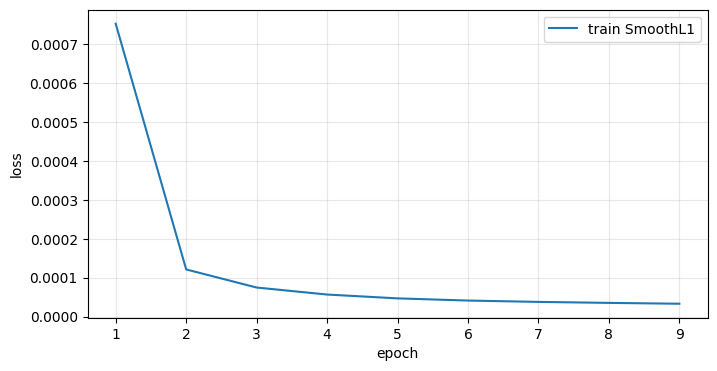

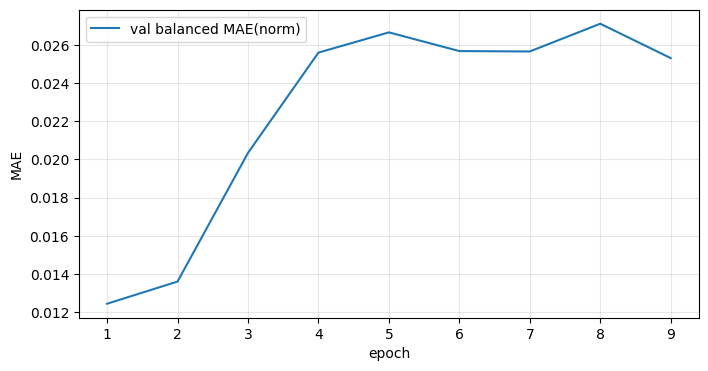

In [ ]:
# 13) 학습 곡선
import json
import matplotlib.pyplot as plt

HISTORY_PATH = RUN_DIR / "fp32" / "history.json"

with open(HISTORY_PATH, "r", encoding="utf-8") as f:
    history = json.load(f)

epochs_x = [h["epoch"] for h in history]
train_loss_y = [h["train_loss"] for h in history]
val_y = [h["val_balanced_mae_norm"] for h in history]

plt.figure(figsize=(8, 4))
plt.plot(epochs_x, train_loss_y, label="train SmoothL1")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(epochs_x, val_y, label="val balanced MAE(norm)")
plt.xlabel("epoch")
plt.ylabel("MAE")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

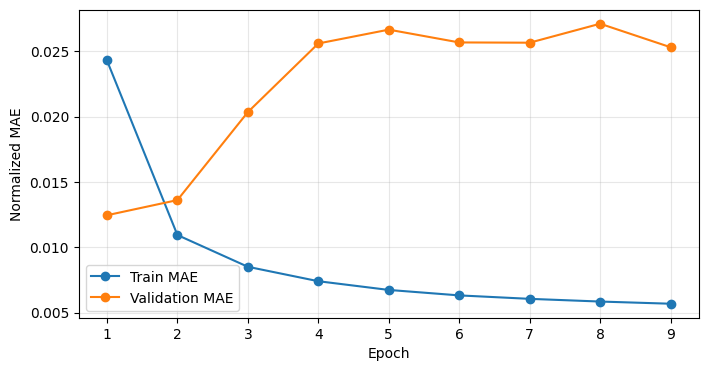

In [ ]:
epochs_x = [h["epoch"] for h in history]

train_mae = [h["train_mae_norm"] for h in history]
val_mae = [h["val_balanced_mae_norm"] for h in history]

plt.figure(figsize=(8, 4))
plt.plot(epochs_x, train_mae, marker="o", label="Train MAE")
plt.plot(epochs_x, val_mae, marker="o", label="Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("Normalized MAE")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [17]:

# 14) Best 모델의 사람×동작 validation score 확인

best_ckpt = torch.load(BEST_PATH, map_location=device, weights_only=False)
model.load_state_dict(best_ckpt["model_state_dict"])
model.eval()

pred, target = predict_all(model, val_ds, BATCH_SIZE, device)
score, group_scores = balanced_val_score(
    pred, target, val_entries, val_window_file_ids
)

print("BEST balanced MAE(norm):", score)
print()

for g, s in sorted(group_scores.items()):
    print(f"{g:20s} : {s:.6f}")


print("\n===== FINAL TEST =====")
if test_ds is None:
    print("Test 파일 없음 -> 최종 Test 평가는 건너뜁니다.")
else:
    test_pred, test_target = predict_all(
        model, test_ds, BATCH_SIZE, device
    )
    test_score, test_group_scores = balanced_val_score(
        test_pred,
        test_target,
        test_entries,
        test_window_file_ids,
    )

    print("TEST balanced MAE(norm):", test_score)
    for g, sc in sorted(test_group_scores.items()):
        print(f"{g:20s} : {sc:.6f}")


NameError: name 'model' is not defined


## INT8 + FPGA weight blob 생성

아래 셀은 **best_model.pt를 다시 로드**한 뒤 calibration하고,
현재 5RX RTL용으로 다음을 만듭니다.

- `weights_int8.npz`
- `model_int8.json`
- `weights_5rx.bin`
- `weight_layout.json`

5RX blob 예상 크기:
**171,284 words = 685,136 bytes**


In [ ]:

# 15) INT8 calibration / export

# weighted sampler가 아니라 실제 train window를 고르게 훑는 calibration loader 사용
CALIBRATION_WINDOWS = 512

calib_count = min(len(train_ds), CALIBRATION_WINDOWS)

if len(train_ds) > calib_count:
    calib_indices = np.linspace(
        0, len(train_ds) - 1, calib_count, dtype=np.int64
    ).tolist()
    calib_ds = Subset(train_ds, calib_indices)
else:
    calib_ds = train_ds

calib_loader = DataLoader(
    calib_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

best_ckpt = torch.load(BEST_PATH, map_location=device, weights_only=False)
model.load_state_dict(best_ckpt["model_state_dict"])
model.eval()

calibration = calibrate_fast_model(
    model,
    calib_loader,
    max_windows=CALIBRATION_WINDOWS,
    activation_percentile=99.999,
    max_observer_samples=262144,
    per_update_samples=16384,
    device=device,
)

metadata = export_fast_cnn_int8(
    model.cpu(),
    INT8_DIR,
    activation_scales=calibration.activation_scales,
    calibration_report={
        "source_checkpoint": str(BEST_PATH),
        "windows_seen": calibration.windows_seen,
        "activation_percentile": 99.999,
        "observers": calibration.observer_summary,
    },
)

print("INT8 export 완료")
print("windows_seen:", calibration.windows_seen)
print(INT8_DIR / "weights_int8.npz")
print(INT8_DIR / "model_int8.json")


In [ ]:

# 16) 현재 5RX RTL blob 포맷으로 pack

WEIGHT_MAGIC = 0x36574C50
WEIGHT_VERSION = 2

def float_to_u32(value):
    return np.uint32(
        struct.unpack("<I", struct.pack("<f", float(value)))[0]
    )

def pack_int8x4_le(array):
    flat = np.asarray(array, dtype=np.int8).reshape(-1)

    if flat.size % 4:
        flat = np.pad(
            flat,
            (0, 4 - flat.size % 4),
            constant_values=0
        ).astype(np.int8)

    u8 = flat.view(np.uint8).reshape(-1, 4).astype(np.uint32)

    packed = (
        u8[:, 0]
        | (u8[:, 1] << 8)
        | (u8[:, 2] << 16)
        | (u8[:, 3] << 24)
    )
    return packed.astype("<u4")

def int32_words(array):
    return np.asarray(array, dtype="<i4").reshape(-1).view("<u4")

def write_words_at(blob, offset, words, name):
    words = np.asarray(words, dtype="<u4")
    end = offset + len(words)
    if end > len(blob):
        raise RuntimeError(f"{name}: blob overflow {end} > {len(blob)}")
    blob[offset:end] = words

def weight_layout(rx):
    o = {
        "magic": 0,
        "version": 1,
        "total_words": 2,
        "input_scale_bits": 3,
        "output_scale_bits": 4,
        "pool_requant_mult": 5,
        "pool_requant_shift": 6,
        "reserved": 7,
    }

    pos = 8

    o["conv1.weight_int8"] = pos
    pos += (16 * 3 * 5 * 3) // 4
    o["conv1.bias_int32"] = pos
    pos += 16
    o["conv1.requant_mult"] = pos
    pos += 16
    o["conv1.requant_shift"] = pos
    pos += 16

    o["conv2.weight_int8"] = pos
    pos += (32 * 16 * 3 * 3) // 4
    o["conv2.bias_int32"] = pos
    pos += 32
    o["conv2.requant_mult"] = pos
    pos += 32
    o["conv2.requant_shift"] = pos
    pos += 32

    assert pos == 1484

    o["fc1.weight_int8"] = pos
    pos += rx * 32768
    o["fc1.bias_int32"] = pos
    pos += 128
    o["fc1.requant_mult"] = pos
    pos += 128
    o["fc1.requant_shift"] = pos
    pos += 128

    o["fc2.weight_int8"] = pos
    pos += (128 * 128) // 4
    o["fc2.bias_int32"] = pos
    pos += 128
    o["fc2.requant_mult"] = pos
    pos += 128
    o["fc2.requant_shift"] = pos
    pos += 128

    o["fc3.weight_int8"] = pos
    pos += (24 * 128) // 4
    o["fc3.bias_int32"] = pos
    pos += 24
    o["fc3.requant_mult"] = pos
    pos += 24
    o["fc3.requant_shift"] = pos
    pos += 24

    for name in [
        "lut.encoder.gelu1.int8",
        "lut.encoder.gelu2.int8",
        "lut.head.gelu1.int8",
        "lut.head.gelu2.int8",
    ]:
        o[name] = pos
        pos += 64

    expected = 7444 + rx * 32768
    assert pos == expected, (pos, expected)

    return o, pos

def write_weight_bin(npz_path, metadata, output_path, rx=5):
    with np.load(npz_path) as z:
        arrays = {k: z[k].copy() for k in z.files}

    if int(metadata["node_count"]) != rx:
        raise RuntimeError(
            f"INT8 metadata node_count={metadata['node_count']} != rx={rx}"
        )

    offsets, total_words = weight_layout(rx)
    blob = np.zeros(total_words, dtype="<u4")

    layers = metadata["layers"]
    scales = metadata["activation_scales"]
    pool = metadata["pool"]

    blob[offsets["magic"]] = np.uint32(WEIGHT_MAGIC)
    blob[offsets["version"]] = np.uint32(WEIGHT_VERSION)
    blob[offsets["total_words"]] = np.uint32(total_words)
    blob[offsets["input_scale_bits"]] = float_to_u32(scales["encoder.input"])
    blob[offsets["output_scale_bits"]] = float_to_u32(scales["head.fc3_out"])

    blob[offsets["pool_requant_mult"]] = int32_words(
        np.array([pool["requant_multiplier"]], dtype=np.int32)
    )[0]

    blob[offsets["pool_requant_shift"]] = int32_words(
        np.array([pool["requant_shift"]], dtype=np.int32)
    )[0]

    for layer_name in ["conv1", "conv2", "fc1", "fc2", "fc3"]:
        write_words_at(
            blob,
            offsets[f"{layer_name}.weight_int8"],
            pack_int8x4_le(arrays[f"{layer_name}.weight_int8"]),
            f"{layer_name}.weight_int8",
        )

        write_words_at(
            blob,
            offsets[f"{layer_name}.bias_int32"],
            int32_words(arrays[f"{layer_name}.bias_int32"]),
            f"{layer_name}.bias_int32",
        )

        write_words_at(
            blob,
            offsets[f"{layer_name}.requant_mult"],
            int32_words(
                np.asarray(
                    layers[layer_name]["requant_multiplier"],
                    dtype=np.int32
                )
            ),
            f"{layer_name}.requant_mult",
        )

        write_words_at(
            blob,
            offsets[f"{layer_name}.requant_shift"],
            int32_words(
                np.asarray(
                    layers[layer_name]["requant_shift"],
                    dtype=np.int32
                )
            ),
            f"{layer_name}.requant_shift",
        )

    for lut_name in [
        "lut.encoder.gelu1.int8",
        "lut.encoder.gelu2.int8",
        "lut.head.gelu1.int8",
        "lut.head.gelu2.int8",
    ]:
        write_words_at(
            blob,
            offsets[lut_name],
            pack_int8x4_le(arrays[lut_name]),
            lut_name,
        )

    output_path.write_bytes(blob.astype("<u4").tobytes())

    layout = {
        "magic": f"0x{WEIGHT_MAGIC:08x}",
        "version": WEIGHT_VERSION,
        "rx": rx,
        "word_bytes": 4,
        "total_words": total_words,
        "total_bytes": total_words * 4,
        "offset_words": offsets,
    }

    (output_path.parent / "weight_layout.json").write_text(
        json.dumps(layout, indent=2),
        encoding="utf-8",
    )

    return total_words

BIN_PATH = INT8_DIR / "weights_5rx.bin"

total_words = write_weight_bin(
    INT8_DIR / "weights_int8.npz",
    metadata,
    BIN_PATH,
    rx=RX_COUNT,
)

expected_words = 171_284
expected_bytes = 685_136

assert total_words == expected_words
assert BIN_PATH.stat().st_size == expected_bytes

print("FPGA blob 생성 완료")
print("path :", BIN_PATH)
print("words:", total_words)
print("bytes:", BIN_PATH.stat().st_size)


In [ ]:

# 17) 최종 생성 파일 확인

print("===== OUTPUT =====")
for p in sorted(RUN_DIR.rglob("*")):
    if p.is_file() and p.suffix in {".pt", ".bin", ".npz", ".json"}:
        print(f"{p.relative_to(RUN_DIR)}  ({p.stat().st_size:,} bytes)")

print("\n핵심 파일")
print("FP32 best :", BEST_PATH)
print("INT8 npz  :", INT8_DIR / "weights_int8.npz")
print("INT8 meta :", INT8_DIR / "model_int8.json")
print("FPGA bin  :", BIN_PATH)


## 이 노트북에서 중요한 점

1. Drive의 `dataset` 폴더에는 **ZIP만** 두면 됩니다.
2. 각 ZIP 하나를 **한 시간대/한 세션**으로 취급합니다.
3. 현재 일반 ZIP이 4개면 **3 Train / 1 Val**로 세션 통째로 나눕니다.
4. 같은 ZIP의 `_1`, `_2`가 Train/Val에 갈라지지 않습니다.
5. 사람 6명은 sampling에서 가능한 한 동일 비중으로 봅니다.
6. 동작 sampling 목표는 **팔 30% / 다리 30% / 스쿼트 30% / 정자세 10%**입니다.
7. 정자세 파일은 `..._정자세.csv`처럼 숫자 없이 써도 됩니다.
8. `*_테스트.zip`은 ZIP 전체가 Test 전용입니다.
9. Test가 없어도 학습은 정상 진행됩니다.
10. 대용량 ZIP/압축 해제 CSV/전처리 NPZ는 **Colab 로컬 `/content`**에만 존재합니다.
11. Drive에는 최종 `best_model.pt`, INT8 파일, FPGA `weights_5rx.bin`, 로그/manifest만 저장합니다.
12. 마지막 FPGA blob 예상 크기는 **685,136 bytes**입니다.

권장 Drive 구성:

```text
wifi_csi/
├─ dataset/
│  ├─ 1002_21시_모션.zip
│  ├─ 1003_11시_모션.zip
│  ├─ 1003_13시_모션.zip
│  ├─ 1003_15시_모션.zip
│  └─ 1004_11시_모션_테스트.zip   # 나중에 필요할 때만
└─ runs/
```


===== FILE CHECK =====
[OK] history.json         8,146 bytes
[OK] best_model.pt        2,730,037 bytes
[OK] last_model.pt        2,730,037 bytes
[--] weights_5rx.bin      없음
[--] weights_int8.npz     없음
[--] model_int8.json      없음
[--] weight_layout.json   없음

===== BEST RESULT =====
Best Epoch             : 1
Best Validation MAE    : 0.012448
Train MAE at Best      : 0.024297
Train Loss at Best     : 0.000752

===== BEST CHECKPOINT =====
Saved Epoch             : 1
Input Channels          : 15
Selected RX             : [0, 1, 2, 3, 4]
Saved Best Val          : 0.012447864624361198
Window Size             : 10
Window Stride           : 1
RX Count                : 5
Subcarriers             : 128

===== PERSON × ACTION VALIDATION =====
다훈::arms               : 0.011602
다훈::legs               : 0.011737
다훈::squat              : 0.010829
민영::arms               : 0.019102
민영::legs               : 0.014759
민영::squat              : 0.011536
예담::arms               : 0.011254
예담::legs         

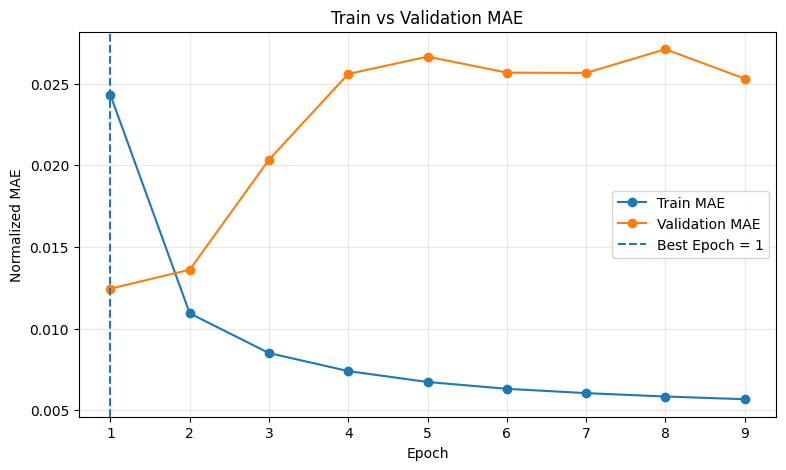

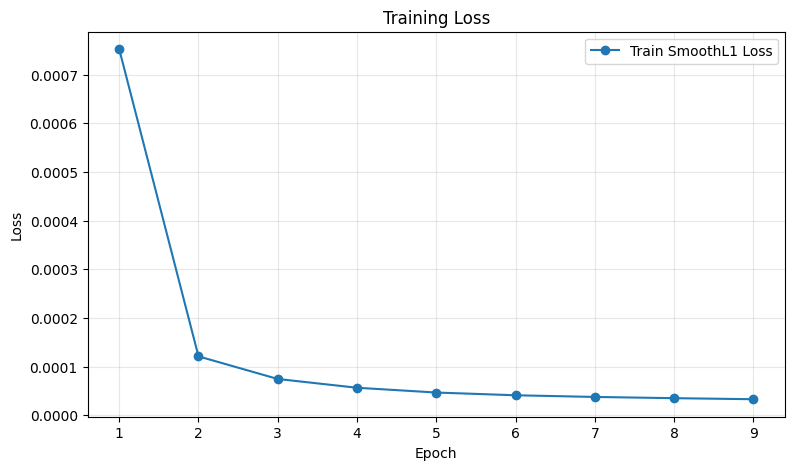


===== FPGA OUTPUT =====
weights_5rx.bin 없음
→ 학습은 완료됐지만 INT8/export 단계가 실행되지 않은 상태일 수 있음

             FINAL SUMMARY
Epochs trained : 9
Best Epoch     : 1
Best Val MAE   : 0.012448
Best model     : /content/drive/MyDrive/wifi_csi/runs/6people_5rx_zip_v1/fp32/best_model.pt
FPGA bin      : 없음


In [16]:
# ============================================================
# v3 학습 결과 확인 전용
# - 이전 셀 실행 필요 없음
# - model / val_ds / history 변수 필요 없음
# - 재학습 없음
# ============================================================

from pathlib import Path
import json
import torch
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 0. Google Drive 확인
# ------------------------------------------------------------
DRIVE_ROOT = Path("/content/drive/MyDrive")

if not DRIVE_ROOT.exists():
    try:
        from google.colab import drive
        drive.mount("/content/drive")
    except ModuleNotFoundError:
        raise RuntimeError(
            "Google Drive가 연결되어 있지 않습니다.\n"
            "Colab 런타임에 연결한 뒤 다시 실행하세요."
        )

# ------------------------------------------------------------
# 1. v3 결과 경로
# ------------------------------------------------------------
RUN_DIR = Path(
    "/content/drive/MyDrive/wifi_csi/runs/6people_5rx_zip_v1"
)

FP32_DIR = RUN_DIR / "fp32"
INT8_DIR = RUN_DIR / "int8"

HISTORY_PATH = FP32_DIR / "history.json"
BEST_PATH = FP32_DIR / "best_model.pt"
LAST_PATH = FP32_DIR / "last_model.pt"

BIN_PATH = INT8_DIR / "weights_5rx.bin"
INT8_NPZ_PATH = INT8_DIR / "weights_int8.npz"
INT8_JSON_PATH = INT8_DIR / "model_int8.json"
LAYOUT_PATH = INT8_DIR / "weight_layout.json"

# ------------------------------------------------------------
# 2. 필수 결과 존재 확인
# ------------------------------------------------------------
print("===== FILE CHECK =====")

files = {
    "history.json": HISTORY_PATH,
    "best_model.pt": BEST_PATH,
    "last_model.pt": LAST_PATH,
    "weights_5rx.bin": BIN_PATH,
    "weights_int8.npz": INT8_NPZ_PATH,
    "model_int8.json": INT8_JSON_PATH,
    "weight_layout.json": LAYOUT_PATH,
}

for name, path in files.items():
    if path.exists():
        print(f"[OK] {name:20s} {path.stat().st_size:,} bytes")
    else:
        print(f"[--] {name:20s} 없음")

if not HISTORY_PATH.exists():
    raise FileNotFoundError(
        f"\nhistory.json이 없습니다.\n경로: {HISTORY_PATH}"
    )

# ------------------------------------------------------------
# 3. history.json 로드
# v3 코드에서는 history 자체를 list로 저장함
# ------------------------------------------------------------
with open(HISTORY_PATH, "r", encoding="utf-8") as f:
    history = json.load(f)

if not isinstance(history, list):
    raise TypeError(
        f"history.json 형식이 예상과 다릅니다: {type(history)}"
    )

if len(history) == 0:
    raise RuntimeError("history.json이 비어 있습니다.")

required_keys = {
    "epoch",
    "train_loss",
    "train_mae_norm",
    "val_balanced_mae_norm",
}

for i, row in enumerate(history):
    missing = required_keys - set(row.keys())
    if missing:
        raise KeyError(
            f"history[{i}]에 필요한 키가 없습니다: {missing}"
        )

# ------------------------------------------------------------
# 4. Validation 기준 Best epoch 계산
# ------------------------------------------------------------
best_row = min(
    history,
    key=lambda x: float(x["val_balanced_mae_norm"])
)

best_epoch = int(best_row["epoch"])
best_val = float(best_row["val_balanced_mae_norm"])
best_train_mae = float(best_row["train_mae_norm"])
best_train_loss = float(best_row["train_loss"])

print("\n===== BEST RESULT =====")
print(f"Best Epoch             : {best_epoch}")
print(f"Best Validation MAE    : {best_val:.6f}")
print(f"Train MAE at Best      : {best_train_mae:.6f}")
print(f"Train Loss at Best     : {best_train_loss:.6f}")

# ------------------------------------------------------------
# 5. best_model.pt 자체 정보 확인
# 모델 객체 생성 필요 없음
# ------------------------------------------------------------
if BEST_PATH.exists():
    try:
        checkpoint = torch.load(
            BEST_PATH,
            map_location="cpu",
            weights_only=False,
        )
    except TypeError:
        checkpoint = torch.load(
            BEST_PATH,
            map_location="cpu",
        )

    print("\n===== BEST CHECKPOINT =====")
    print("Saved Epoch             :", checkpoint.get("epoch"))
    print("Input Channels          :", checkpoint.get("input_channels"))
    print("Selected RX             :", checkpoint.get("selected_rx"))
    print(
        "Saved Best Val          :",
        checkpoint.get("best_val_score_norm_mae")
    )

    cfg = checkpoint.get("config", {})
    if cfg:
        print("Window Size             :", cfg.get("window_size"))
        print("Window Stride           :", cfg.get("window_stride"))
        print("RX Count                :", cfg.get("rx_count"))
        print("Subcarriers             :", cfg.get("subcarriers"))

# ------------------------------------------------------------
# 6. Best epoch의 사람 × 동작 Validation 결과
# ------------------------------------------------------------
group_scores = best_row.get("group_scores", {})

print("\n===== PERSON × ACTION VALIDATION =====")

if group_scores:
    for group, score in sorted(group_scores.items()):
        print(f"{group:22s} : {float(score):.6f}")
else:
    print("group_scores 없음")

# ------------------------------------------------------------
# 7. 사람별 평균 / 동작별 평균
# ------------------------------------------------------------
person_scores = {}
action_scores = {}

for group, score in group_scores.items():
    if "::" not in group:
        continue

    person, action = group.split("::", 1)
    score = float(score)

    person_scores.setdefault(person, []).append(score)
    action_scores.setdefault(action, []).append(score)

if person_scores:
    print("\n===== PERSON AVERAGE =====")
    for person, scores in sorted(person_scores.items()):
        avg = sum(scores) / len(scores)
        print(f"{person:8s} : {avg:.6f}")

if action_scores:
    print("\n===== ACTION AVERAGE =====")
    for action, scores in sorted(action_scores.items()):
        avg = sum(scores) / len(scores)
        print(f"{action:8s} : {avg:.6f}")

# ------------------------------------------------------------
# 8. Train MAE vs Validation MAE
# ------------------------------------------------------------
epochs = [int(h["epoch"]) for h in history]
train_mae = [float(h["train_mae_norm"]) for h in history]
val_mae = [float(h["val_balanced_mae_norm"]) for h in history]

plt.figure(figsize=(9, 5))

plt.plot(
    epochs,
    train_mae,
    marker="o",
    label="Train MAE",
)

plt.plot(
    epochs,
    val_mae,
    marker="o",
    label="Validation MAE",
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best Epoch = {best_epoch}",
)

plt.xlabel("Epoch")
plt.ylabel("Normalized MAE")
plt.title("Train vs Validation MAE")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# ------------------------------------------------------------
# 9. Train Loss
# ------------------------------------------------------------
train_loss = [
    float(h["train_loss"])
    for h in history
]

plt.figure(figsize=(9, 5))

plt.plot(
    epochs,
    train_loss,
    marker="o",
    label="Train SmoothL1 Loss",
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# ------------------------------------------------------------
# 10. FPGA BIN 검사
# ------------------------------------------------------------
print("\n===== FPGA OUTPUT =====")

if BIN_PATH.exists():
    bin_size = BIN_PATH.stat().st_size

    print("BIN path :", BIN_PATH)
    print(f"BIN size : {bin_size:,} bytes")

    if bin_size == 685_136:
        print("BIN check: OK (5RX 예상 크기와 일치)")
    else:
        print(
            "BIN check: WARNING "
            f"(5RX 예상 685,136 bytes / 실제 {bin_size:,} bytes)"
        )
else:
    print("weights_5rx.bin 없음")
    print("→ 학습은 완료됐지만 INT8/export 단계가 실행되지 않은 상태일 수 있음")

# ------------------------------------------------------------
# 11. 최종 요약
# ------------------------------------------------------------
print("\n========================================")
print("             FINAL SUMMARY")
print("========================================")
print(f"Epochs trained : {len(history)}")
print(f"Best Epoch     : {best_epoch}")
print(f"Best Val MAE   : {best_val:.6f}")
print(f"Best model     : {BEST_PATH}")
print(
    "FPGA bin      :",
    BIN_PATH if BIN_PATH.exists() else "없음"
)
print("========================================")